In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# 1. Load Dataset

In [2]:
df = pd.read_excel('/content/data set.xlsx')

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nFirst 5 Rows:")
print(df.head())



Dataset Shape: (1200, 14)

Columns:
Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='object')

First 5 Rows:
     OrderID       Date CustomerID  Product  Quantity  UnitPrice  \
0  ORD200000 2023-01-04     C72649  Monitor         5     570.62   
1  ORD200001 2024-08-23     C75739    Phone         2     151.35   
2  ORD200002 2024-02-27     C81728   Tablet         5     550.68   
3  ORD200003 2023-10-15     C33540    Chair         1     273.19   
4  ORD200004 2025-05-08     C81840  Printer         4     626.01   

  ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0     928 Main St    Debit Card     Shipped    TRK37947903            7   
1     823 Main St        Online     Shipped    TRK91186779            3   
2     512 Main St   Credit Card   Cancelled    TRK42903982            8 

# 2. Dataset Information

In [3]:
print("\nDataset Information:")
print(df.info())



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](

In [4]:

print("\nChecking Duplicates:")
print("Duplicate Rows:", df.duplicated().sum())


Checking Duplicates:
Duplicate Rows: 0


# 3. Missing Value Analysis

In [5]:
print("\nMissing Values:")
missing_values = df.isnull().sum()

missing_percentage = (
    missing_values / len(df)
) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percentage
})

print(missing_df)


Missing Values:
                 Missing Values  Percentage
OrderID                       0        0.00
Date                          0        0.00
CustomerID                    0        0.00
Product                       0        0.00
Quantity                      0        0.00
UnitPrice                     0        0.00
ShippingAddress               0        0.00
PaymentMethod                 0        0.00
OrderStatus                   0        0.00
TrackingNumber                0        0.00
ItemsInCart                   0        0.00
CouponCode                  309       25.75
ReferralSource                0        0.00
TotalPrice                    0        0.00


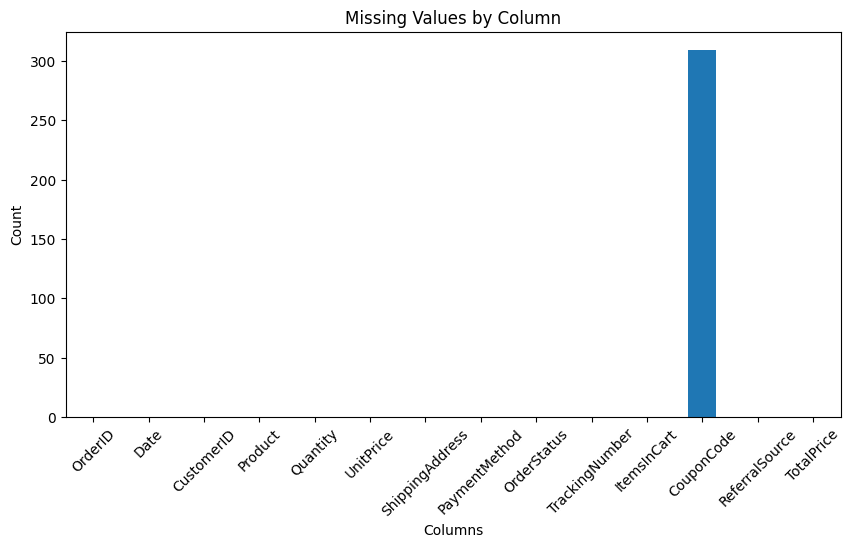

In [6]:
plt.figure(figsize=(10,5))
missing_values.plot(kind='bar')
plt.title('Missing Values by Column')
plt.xlabel('Columns')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


# 4. Data Cleaning

In [7]:
# Convert Date Column
df['Date'] = pd.to_datetime(df['Date'])

In [8]:
# Fill Missing Coupon Codes
df['CouponCode'] = df['CouponCode'].fillna('No Coupon')

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())



Missing Values After Cleaning:
OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
dtype: int64


# 5. Descriptive Statistics


In [9]:
print("\nDescriptive Statistics:")
print(df.describe())


Descriptive Statistics:
                      Date     Quantity    UnitPrice  ItemsInCart   TotalPrice
count                 1200  1200.000000  1200.000000  1200.000000  1200.000000
mean   2024-03-22 16:58:48     2.945833   356.412750     5.485000  1053.968300
min    2023-01-01 00:00:00     1.000000    11.390000     1.000000    11.390000
25%    2023-08-03 18:00:00     2.000000   186.062500     4.000000   410.520000
50%    2024-03-23 00:00:00     3.000000   364.210000     5.000000   823.615000
75%    2024-11-08 12:00:00     4.000000   521.570000     7.000000  1578.475000
max    2025-06-30 00:00:00     5.000000   699.930000    10.000000  3456.400000
std                    NaN     1.407557   197.177146     2.281983   819.856558


In [10]:
print("\nCategorical Statistics:")
print(df.describe(include='object'))


Categorical Statistics:
          OrderID CustomerID  Product ShippingAddress PaymentMethod  \
count        1200       1200     1200            1200          1200   
unique       1200       1189        7             655             5   
top     ORD201183     C46651  Printer     533 Main St        Online   
freq            1          2      181               8           258   

       OrderStatus TrackingNumber CouponCode ReferralSource  
count         1200           1200       1200           1200  
unique           5           1200          4              5  
top      Cancelled    TRK83653396   FREESHIP      Instagram  
freq           250              1        313            259  


# 6. Distribution Plots

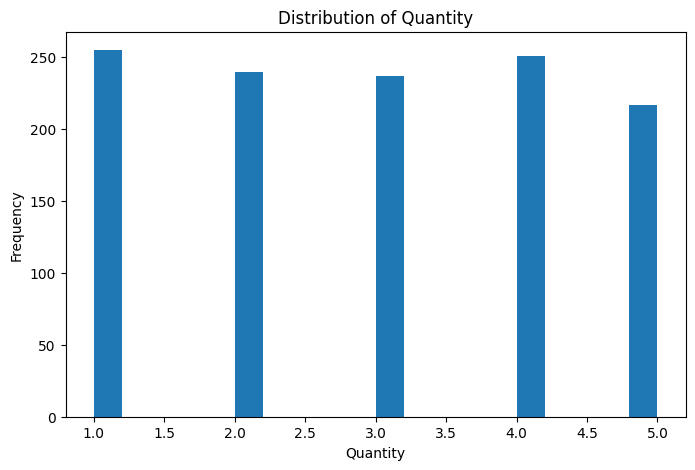

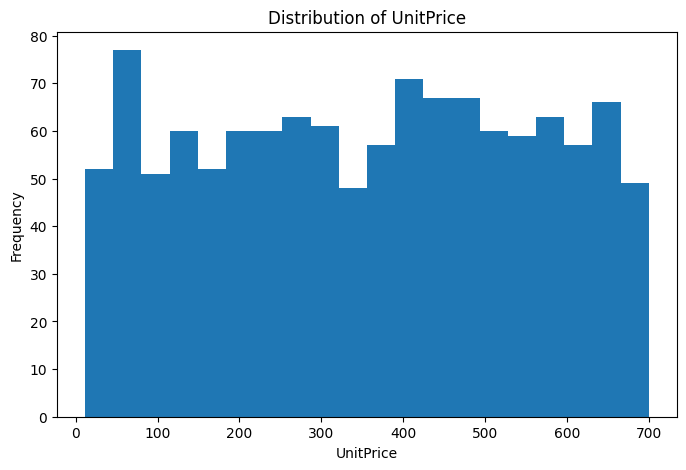

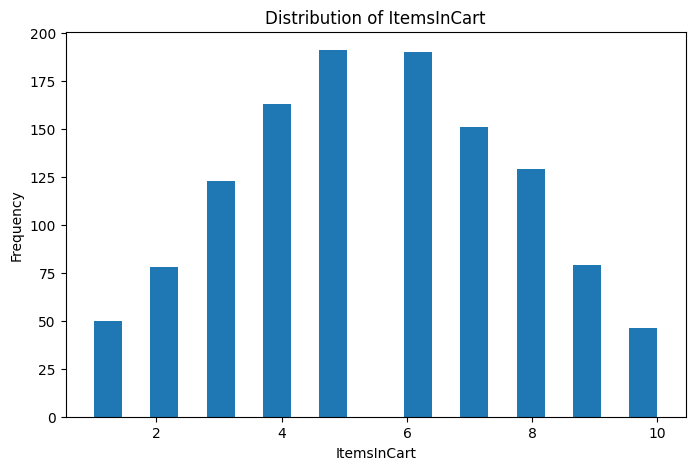

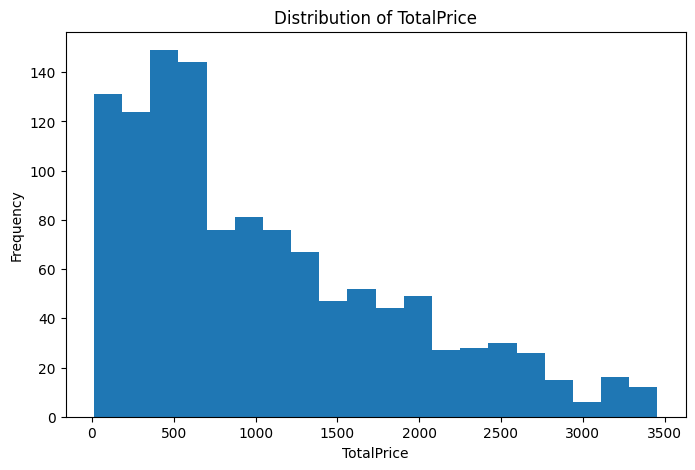

In [11]:


numeric_cols = [
    'Quantity',
    'UnitPrice',
    'ItemsInCart',
    'TotalPrice'
]

for col in numeric_cols:
    plt.figure(figsize=(8,5))

    plt.hist(
        df[col],
        bins=20
    )

    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

    plt.show()

# 7. Boxplots for Outliers

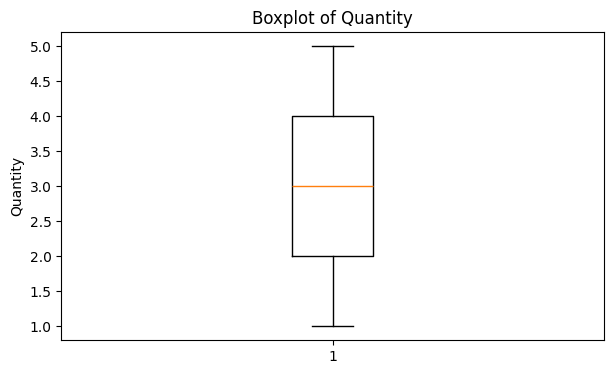

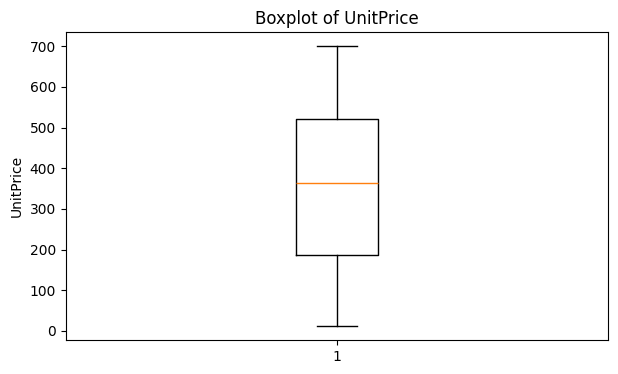

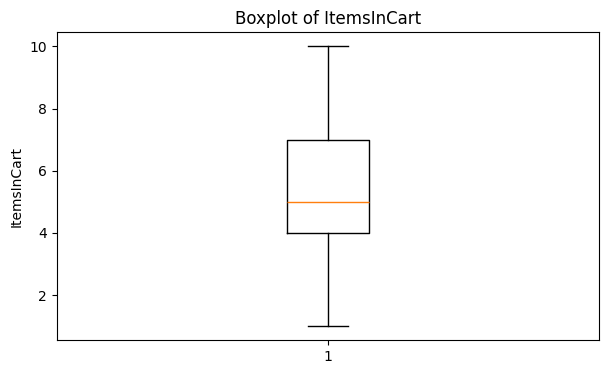

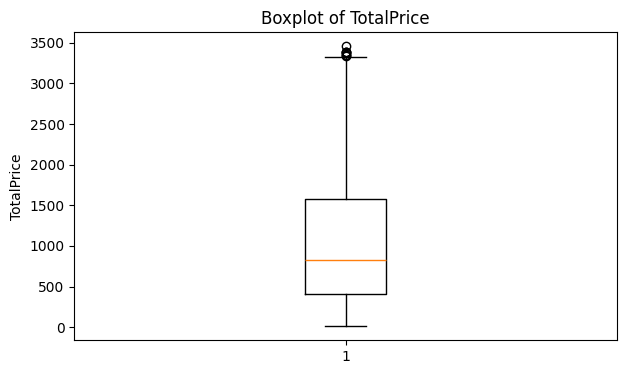

In [12]:
for col in numeric_cols:
    plt.figure(figsize=(7,4))

    plt.boxplot(df[col])

    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)

    plt.show()

# 8. IQR Outlier Detection

In [13]:
for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    print(f"\n{col}")
    print("Outliers:", len(outliers))



Quantity
Outliers: 0

UnitPrice
Outliers: 0

ItemsInCart
Outliers: 0

TotalPrice
Outliers: 8


# 9. Correlation Heatmap


Correlation Matrix:
             Quantity  UnitPrice  ItemsInCart  TotalPrice
Quantity     1.000000   0.014553     0.650061    0.615251
UnitPrice    0.014553   1.000000     0.000602    0.717081
ItemsInCart  0.650061   0.000602     1.000000    0.392540
TotalPrice   0.615251   0.717081     0.392540    1.000000


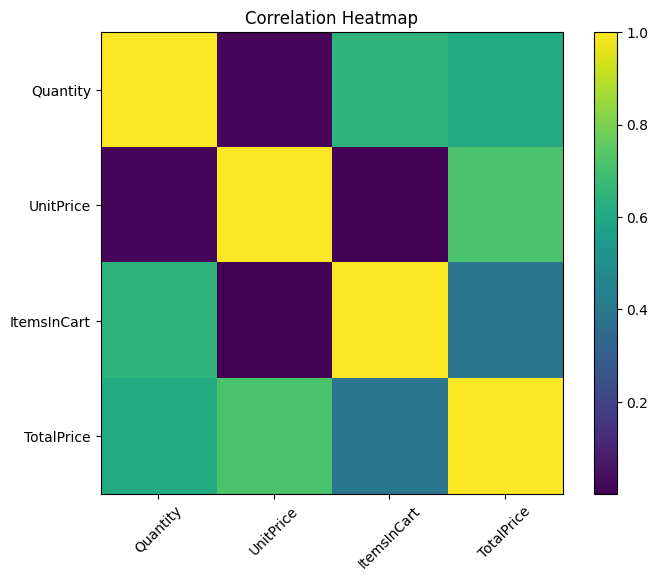

In [14]:

correlation = df[numeric_cols].corr()

print("\nCorrelation Matrix:")
print(correlation)

plt.figure(figsize=(8,6))

heatmap = plt.imshow(correlation)

plt.colorbar(heatmap)

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Heatmap")

plt.show()

# 10. Revenue Trend Analysis

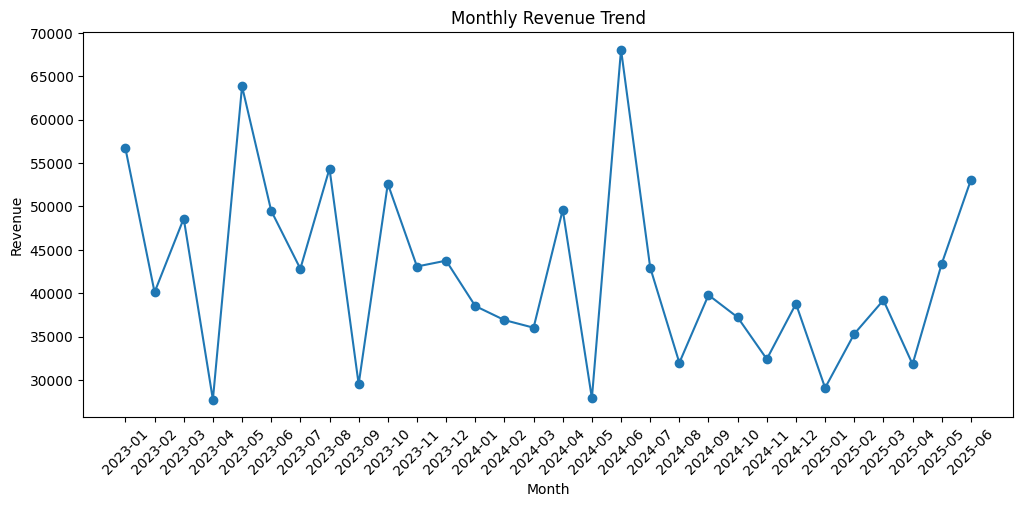

In [15]:
monthly_sales = (
    df.groupby(
        df['Date'].dt.to_period('M')
    )['TotalPrice']
    .sum()
)

plt.figure(figsize=(12,5))

plt.plot(
    monthly_sales.index.astype(str),
    monthly_sales.values,
    marker='o'
)

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.xticks(rotation=45)

plt.show()


# 11. Product Analysis


Top 10 Products:
Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: count, dtype: int64


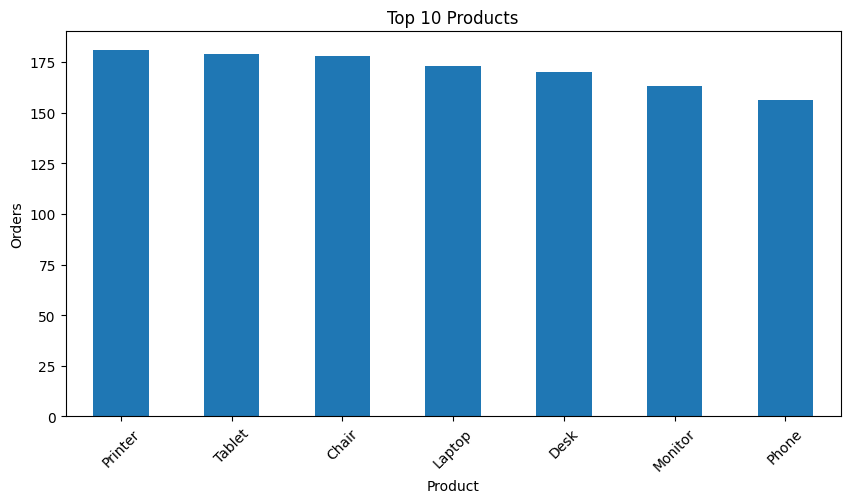

In [16]:
top_products = (
    df['Product']
    .value_counts()
    .head(10)
)

print("\nTop 10 Products:")
print(top_products)

plt.figure(figsize=(10,5))

top_products.plot(kind='bar')

plt.title('Top 10 Products')
plt.xlabel('Product')
plt.ylabel('Orders')

plt.xticks(rotation=45)

plt.show()

# 12. Payment Method Analysis


Payment Methods:
PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64


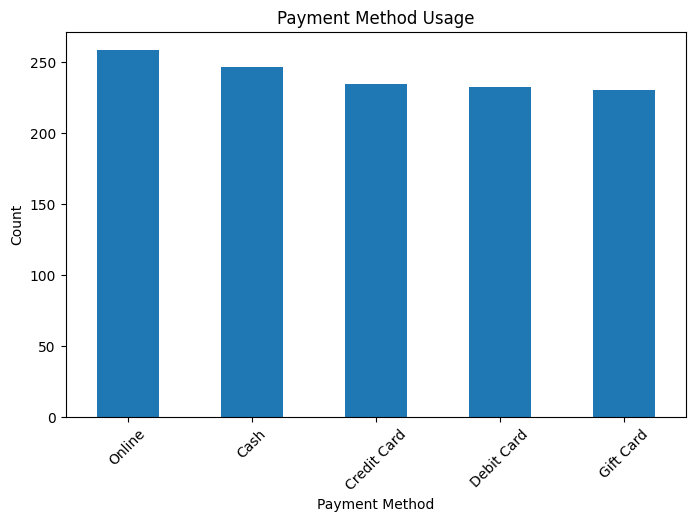

In [17]:
payment_counts = (
    df['PaymentMethod']
    .value_counts()
)

print("\nPayment Methods:")
print(payment_counts)

plt.figure(figsize=(8,5))

payment_counts.plot(kind='bar')

plt.title('Payment Method Usage')
plt.xlabel('Payment Method')
plt.ylabel('Count')

plt.xticks(rotation=45)

plt.show()

# 13. Key Insights

In [18]:

print("\n========== KEY INSIGHTS ==========")

print(
    f"Total Orders: {len(df)}"
)

print(
    f"Average Order Value: ₹{df['TotalPrice'].mean():.2f}"
)

print(
    f"Maximum Order Value: ₹{df['TotalPrice'].max():.2f}"
)

print(
    f"Most Used Payment Method: "
    f"{payment_counts.idxmax()}"
)

print(
    f"Top Selling Product: "
    f"{top_products.idxmax()}"
)

print(
    f"Coupon Codes Missing Before Cleaning: "
    f"{missing_values['CouponCode']}"
)



========== KEY INSIGHTS ==========
Total Orders: 1200
Average Order Value: ₹1053.97
Maximum Order Value: ₹3456.40
Most Used Payment Method: Online
Top Selling Product: Printer
Coupon Codes Missing Before Cleaning: 309


# 14 . Coupon Code Analysis


Coupon Code Usage:
CouponCode
FREESHIP     313
No Coupon    309
WINTER15     292
SAVE10       286
Name: count, dtype: int64


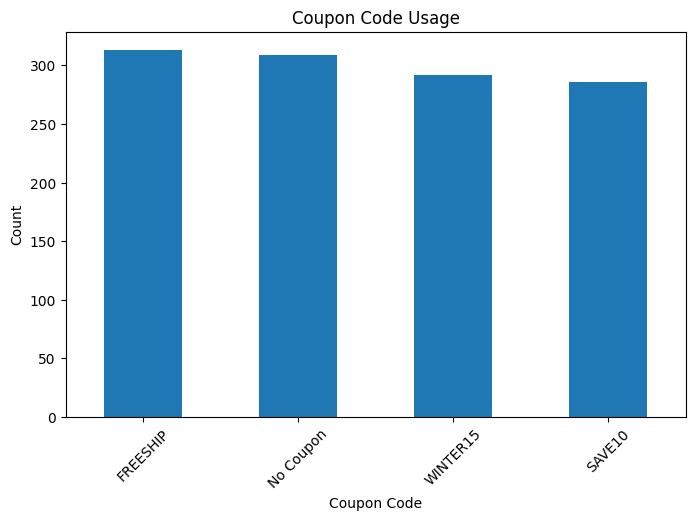

In [21]:
print("\nCoupon Code Usage:")

coupon_usage = df['CouponCode'].value_counts()

print(coupon_usage)

plt.figure(figsize=(8,5))
coupon_usage.plot(kind='bar')

plt.title('Coupon Code Usage')
plt.xlabel('Coupon Code')
plt.ylabel('Count')

plt.xticks(rotation=45)
plt.show()

# 15 . Referral  Source Analysis


Referral Source Analysis
ReferralSource
Instagram    259
Email        250
Google       241
Facebook     228
Referral     222
Name: count, dtype: int64


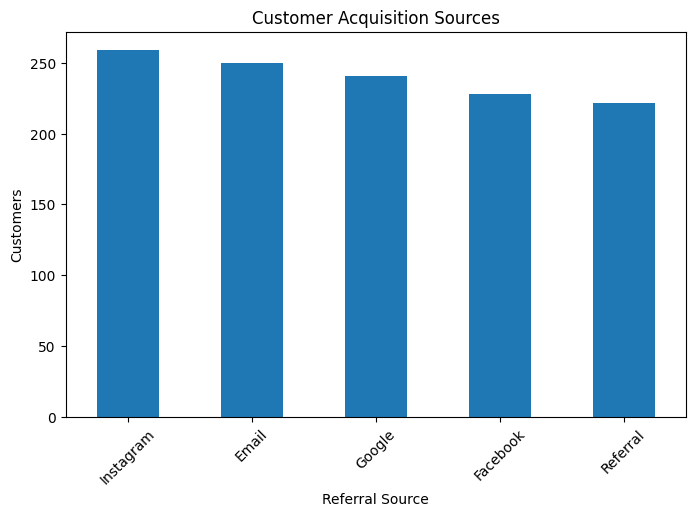

In [22]:
print("\nReferral Source Analysis")

referral = df['ReferralSource'].value_counts()

print(referral)

plt.figure(figsize=(8,5))
referral.plot(kind='bar')

plt.title('Customer Acquisition Sources')
plt.xlabel('Referral Source')
plt.ylabel('Customers')

plt.xticks(rotation=45)
plt.show()

# 16. Order Status Analysis


Order Status Analysis
OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64


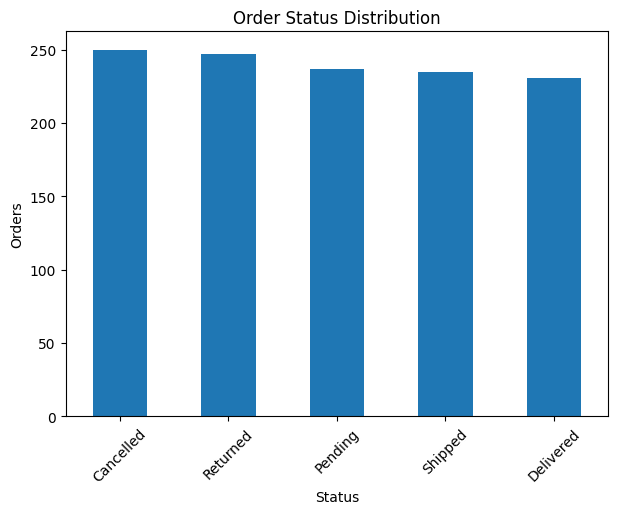

In [23]:
print("\nOrder Status Analysis")

status = df['OrderStatus'].value_counts()

print(status)

plt.figure(figsize=(7,5))
status.plot(kind='bar')

plt.title('Order Status Distribution')
plt.xlabel('Status')
plt.ylabel('Orders')

plt.xticks(rotation=45)
plt.show()

# 17. Average Revenue by Payment Method

PaymentMethod
Cash           1056.041829
Credit Card    1127.553974
Debit Card     1001.556810
Gift Card      1070.973565
Online         1017.220698
Name: TotalPrice, dtype: float64


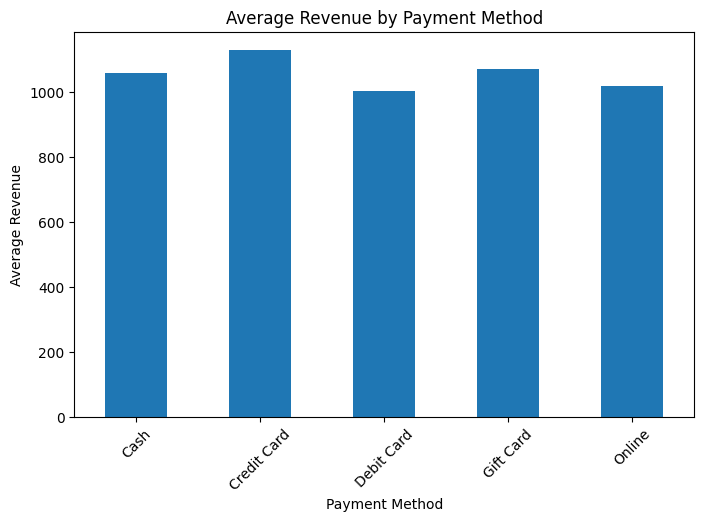

In [24]:
avg_payment = df.groupby('PaymentMethod')['TotalPrice'].mean()

print(avg_payment)

plt.figure(figsize=(8,5))
avg_payment.plot(kind='bar')

plt.title('Average Revenue by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Average Revenue')

plt.xticks(rotation=45)
plt.show()

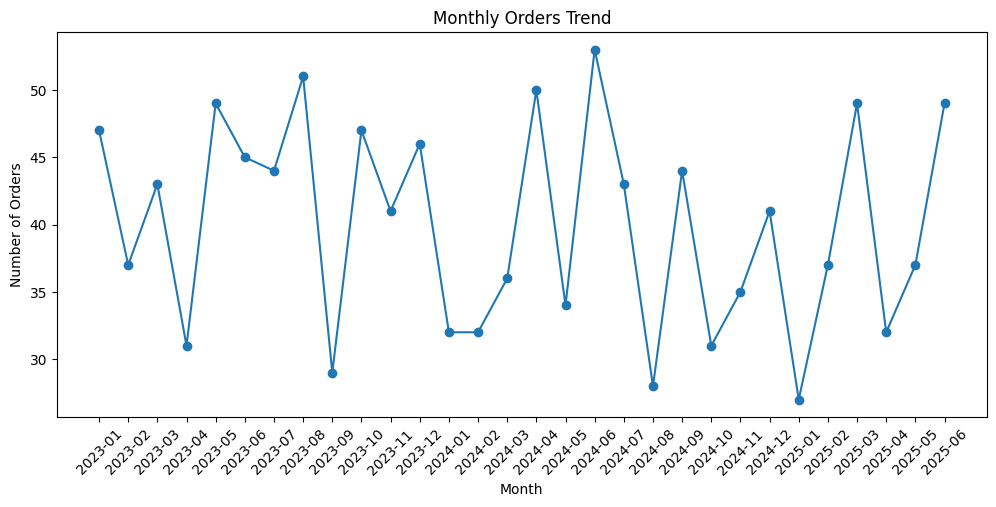

In [25]:
monthly_orders = df.groupby(
    df['Date'].dt.to_period('M')
).size()

plt.figure(figsize=(12,5))

plt.plot(
    monthly_orders.index.astype(str),
    monthly_orders.values,
    marker='o'
)

plt.title('Monthly Orders Trend')
plt.xlabel('Month')
plt.ylabel('Number of Orders')

plt.xticks(rotation=45)

plt.show()

CustomerID
C38840    5723.23
C57276    3456.40
C67260    3390.80
C13877    3384.90
C18404    3370.20
C16775    3353.75
C65986    3352.40
C47778    3334.00
C59183    3322.55
C25276    3313.90
Name: TotalPrice, dtype: float64


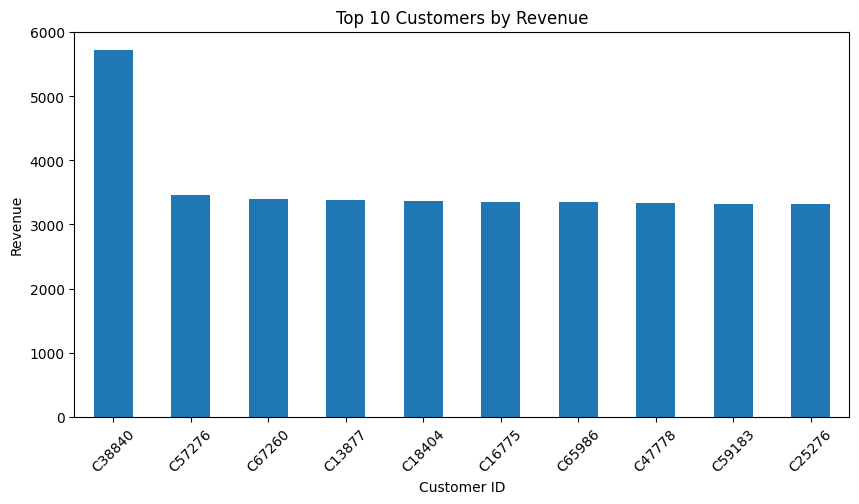

In [26]:
customer_spending = df.groupby(
    'CustomerID'
)['TotalPrice'].sum()

top_customers = customer_spending.sort_values(
    ascending=False
).head(10)

print(top_customers)

plt.figure(figsize=(10,5))

top_customers.plot(kind='bar')

plt.title('Top 10 Customers by Revenue')
plt.xlabel('Customer ID')
plt.ylabel('Revenue')

plt.xticks(rotation=45)

plt.show()

CustomerID
C38840    5723.23
C57276    3456.40
C67260    3390.80
C13877    3384.90
C18404    3370.20
C16775    3353.75
C65986    3352.40
C47778    3334.00
C59183    3322.55
C25276    3313.90
Name: TotalPrice, dtype: float64


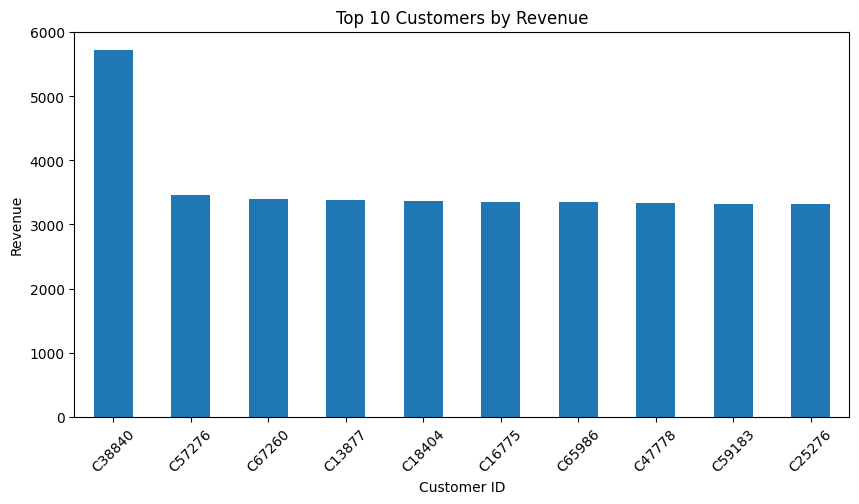

In [27]:
customer_spending = df.groupby(
    'CustomerID'
)['TotalPrice'].sum()

top_customers = customer_spending.sort_values(
    ascending=False
).head(10)

print(top_customers)

plt.figure(figsize=(10,5))

top_customers.plot(kind='bar')

plt.title('Top 10 Customers by Revenue')
plt.xlabel('Customer ID')
plt.ylabel('Revenue')

plt.xticks(rotation=45)

plt.show()

In [28]:
print("\n===== KPI DASHBOARD =====")

print("Total Orders:", len(df))

print("Total Revenue: ₹",
      round(df['TotalPrice'].sum(), 2))

print("Average Order Value: ₹",
      round(df['TotalPrice'].mean(), 2))

print("Unique Customers:",
      df['CustomerID'].nunique())


===== KPI DASHBOARD =====
Total Orders: 1200
Total Revenue: ₹ 1264761.96
Average Order Value: ₹ 1053.97
Unique Customers: 1189


# EXECUTIVE SUMMARY

The EDA identified that the dataset contains
1,200 ecommerce transactions with minimal
data quality issues.

CouponCode was the only column with missing
values. Revenue is strongly influenced by
UnitPrice and Quantity.

The TotalPrice distribution indicates the
presence of high-value transactions, making
premium products significant contributors
to overall revenue.

These insights can support pricing,
marketing, and inventory decisions.